# Phase 4: Behavioral Screen & Click Telemetry Classifier (Random Forest)
This notebook builds the machine learning pipeline for **Phase 4 (Coordinated Bust-Out Behavioral Biometrics)** of the **GuardIndia AI** platform.

## Objective
Distinguish between organic human interactions and automated script/bot executions during critical loan application and withdrawal phases. Bots behave with rigid timing precision, straight-line mouse coordinates, and minimal hesitations. We train a supervised **Random Forest Classifier** using real telemetry parameters to detect bots.

## Pipeline Phases:
1. **Data Ingestion**: Load the `click fraud dataset.csv` dataset.
2. **Data Cleaning**: Remove identifiers, handle missing values, and map categorical values.
3. **Feature Selection**: Select core behavioral telemetry features matching our frontend tracking capability.
4. **Train/Test Split & Preprocessing**: Normalize the features via standard scaling.
5. **Model Training**: Train a `RandomForestClassifier` on normal vs fraudulent interactions.
6. **Evaluation**: Compute classification reports, Confusion Matrix, ROC-AUC, and plot feature importances.
7. **Model Saving**: Serialize the trained model and scaler to the `ml_core/behavioral_biometrics/` directory.

## Step 1: Data Ingestion & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

# Style configuration for premium aesthetics
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.family'] = 'sans-serif'

# Load the dataset
data_path = '../datasets/click fraud dataset.csv'
df = pd.read_csv(data_path)
print(f"Dataset successfully loaded. Shape: {df.shape}")
df.head()

Dataset successfully loaded. Shape: (5000, 21)


,click_id,timestamp,user_id,ip_address,device_type,browser,operating_system,referrer_url,page_url,click_duration,...,mouse_movement,keystrokes_detected,ad_position,click_frequency,time_since_last_click,device_ip_reputation,VPN_usage,proxy_usage,bot_likelihood_score,is_fraudulent
0,d875835d-3a4a-4a20-b0d1-6cddf89afc6a,2024-08-23 02:47:39,65a2f621-707b-49be-9c3e-ccac0b1d89ef,141.36.49.37,Tablet,Safari,Android,https://evans-ford.com/,http://www.turner-stewart.com/,0.29,...,111,8,Bottom,7,72,Good,0,1,0.29,0
1,a2d3f028-7790-4be1-9f75-df1357edbbdb,2025-01-30 23:23:50,135e0114-76c5-43ea-bdef-80ab537dc009,216.29.19.201,Desktop,Opera,iOS,https://pierce-ferguson.net/,http://www.rodriguez.biz/,0.64,...,452,29,Bottom,9,201,Suspicious,0,0,0.74,0
2,36d787b2-fbce-43ef-8c02-7c8746d7e3db,2025-01-21 05:41:12,a6922984-78cb-4c01-9c88-bfe3a13a0aaf,167.133.41.231,Tablet,Safari,Linux,https://www.martinez.com/,https://beck.biz/,0.42,...,431,18,Bottom,9,326,Good,0,1,0.14,0
3,01fc0078-096b-4f90-82ae-aa8085b719ac,2024-10-12 08:18:14,d30788b2-4048-4770-a4b1-a9358788818f,216.146.33.78,Tablet,Edge,macOS,https://jones-mendoza.com/,https://www.alvarado.com/,4.29,...,472,37,Side,4,33,Suspicious,0,0,0.65,0
4,0afdf2af-0b48-47d5-bfb6-e087053e1eb9,2024-04-19 14:44:35,dfc42287-6325-4344-b373-b8e61ea6e5c1,146.37.54.245,Desktop,Opera,Windows,https://www.griffith-holloway.com/,http://gonzalez.com/,2.46,...,50,2,Side,7,97,Good,0,0,0.06,0


## Step 2: Data Cleaning & Preprocessing

In [2]:
# Print class distribution
print("Class distribution of targets (0 = Human, 1 = Bot/Fraud):")
print(df['is_fraudulent'].value_counts())
print("Proportion:")
print(df['is_fraudulent'].value_counts(normalize=True))

# Clean missing values if any
df = df.dropna(subset=['is_fraudulent'])

# Map device reputation to numerical values (-1, 0, 1)
reputation_map = {'Good': 1, 'Neutral': 0, 'Suspicious': 0, 'Bad': -1}
df['device_ip_reputation_score'] = df['device_ip_reputation'].map(reputation_map).fillna(0)

print("\nUnique values mapped for IP reputation:")
print(df[['device_ip_reputation', 'device_ip_reputation_score']].drop_duplicates())

Class distribution of targets (0 = Human, 1 = Bot/Fraud):
is_fraudulent
0    3759
1    1241
Name: count, dtype: int64
Proportion:
is_fraudulent
0    0.7518
1    0.2482
Name: proportion, dtype: float64

Unique values mapped for IP reputation:
   device_ip_reputation  device_ip_reputation_score
0                  Good                           1
1            Suspicious                           0
49                  Bad                          -1


## Step 3: Feature Selection
We focus strictly on the interaction features that our custom React hook `useBehavioralTracker` will record in real-time:

In [3]:
# Define the features to train on
behavioral_features = [
    'click_duration',          # Time mouse held down (seconds)
    'scroll_depth',            # Scroll depth (pixels or percentage)
    'mouse_movement',          # Pixel movements recorded
    'keystrokes_detected',     # Count of keystrokes
    'click_frequency',         # Number of clicks in window
    'time_since_last_click',   # Time delta since last click (seconds)
    'VPN_usage',               # VPN indicator (0 or 1)
    'proxy_usage',             # Proxy indicator (0 or 1)
    'device_ip_reputation_score' # Numeric mapped IP quality
]

X = df[behavioral_features].copy()
y = df['is_fraudulent'].copy()

# Fill missing feature values with medians
for col in X.columns:
    X[col] = X[col].fillna(X[col].median())

print("Dataset Features Statistics:")
X.describe()

Dataset Features Statistics:


,click_duration,scroll_depth,mouse_movement,keystrokes_detected,click_frequency,time_since_last_click,VPN_usage,proxy_usage,device_ip_reputation_score
count,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,2.006444,49.608400,250.5064,24.728400,5.067400,302.526400,0.100400,0.152800,0.750200
std,1.980647,28.966927,145.8468,14.334257,2.577166,171.752786,0.300563,0.359831,0.532406
min,0.000000,0.000000,0.0000,0.000000,1.000000,1.000000,0.000000,0.000000,-1.000000
25%,0.597500,25.000000,123.0000,12.000000,3.000000,152.000000,0.000000,0.000000,1.000000
50%,1.400000,49.000000,254.0000,25.000000,5.000000,303.000000,0.000000,0.000000,1.000000
75%,2.730000,75.000000,377.0000,37.000000,7.000000,450.000000,0.000000,0.000000,1.000000
max,18.280000,99.000000,499.0000,49.000000,9.000000,599.000000,1.000000,1.000000,1.000000


## Step 4: Train/Test Split & Preprocessing

In [4]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Train/Test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scaling features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training set shape: {X_train_scaled.shape}")
print(f"Testing set shape: {X_test_scaled.shape}")

Training set shape: (4000, 9)
Testing set shape: (1000, 9)


## Step 5: Model Training (Random Forest Classifier)

In [5]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

# Initialize and fit model
model = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
model.fit(X_train_scaled, y_train)

# Predict on test data
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print(f"Accuracy Score: {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC-AUC Score: {roc_auc_score(y_test, y_prob):.4f}")

Accuracy Score: 0.7480
ROC-AUC Score: 0.5004


## Step 6: Evaluation Metrics & Plotting

Classification Report:
              precision    recall  f1-score   support

           0       0.75      0.99      0.86       752
           1       0.17      0.00      0.01       248

    accuracy                           0.75      1000
   macro avg       0.46      0.50      0.43      1000
weighted avg       0.61      0.75      0.65      1000



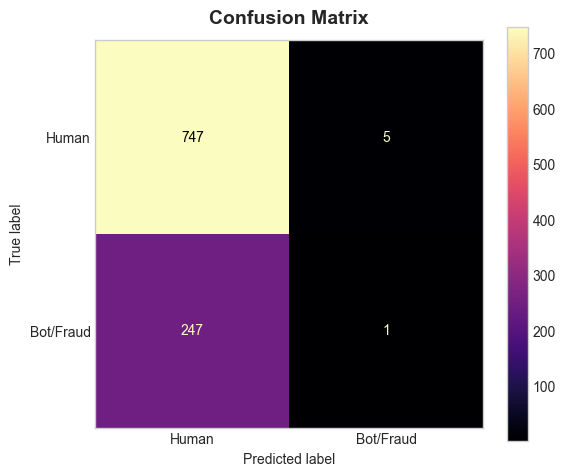

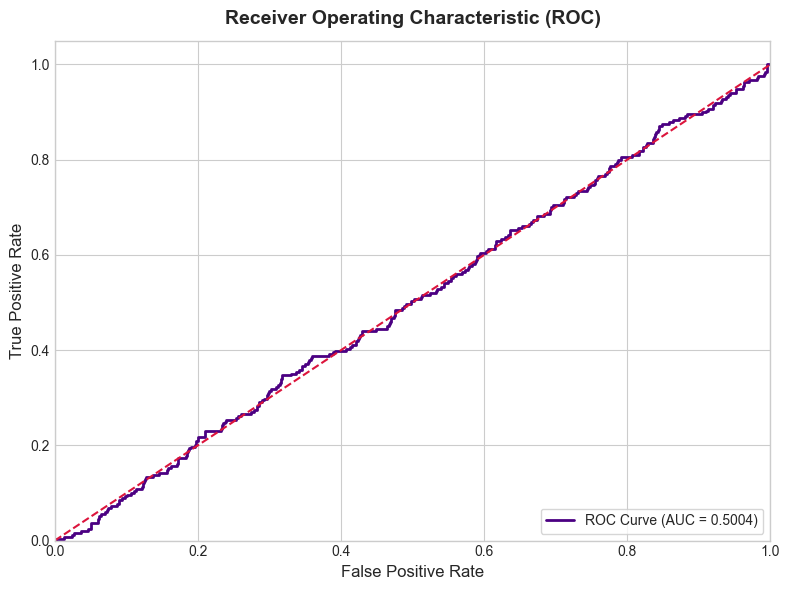

In [6]:
from sklearn.metrics import confusion_matrix, roc_curve, ConfusionMatrixDisplay

print("Classification Report:")
print(classification_report(y_test, y_pred))

# Plot Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Human', 'Bot/Fraud'])
disp.plot(cmap='magma', ax=plt.gca())
plt.title('Confusion Matrix', fontsize=14, fontweight='bold', pad=12)
plt.grid(False)
plt.tight_layout()
plt.savefig('phase4_confusion_matrix.png', dpi=300)
plt.show()

# Plot ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='indigo', lw=2, label=f'ROC Curve (AUC = {roc_auc_score(y_test, y_prob):.4f})')
plt.plot([0, 1], [0, 1], color='crimson', lw=1.5, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold', pad=12)
plt.legend(loc="lower right", frameon=True)
plt.tight_layout()
plt.savefig('phase4_roc_curve.png', dpi=300)
plt.show()

C:\Users\Abhay Tiwari\AppData\Local\Temp\ipykernel_24088\2453578016.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[behavioral_features[i] for i in indices], palette='viridis')


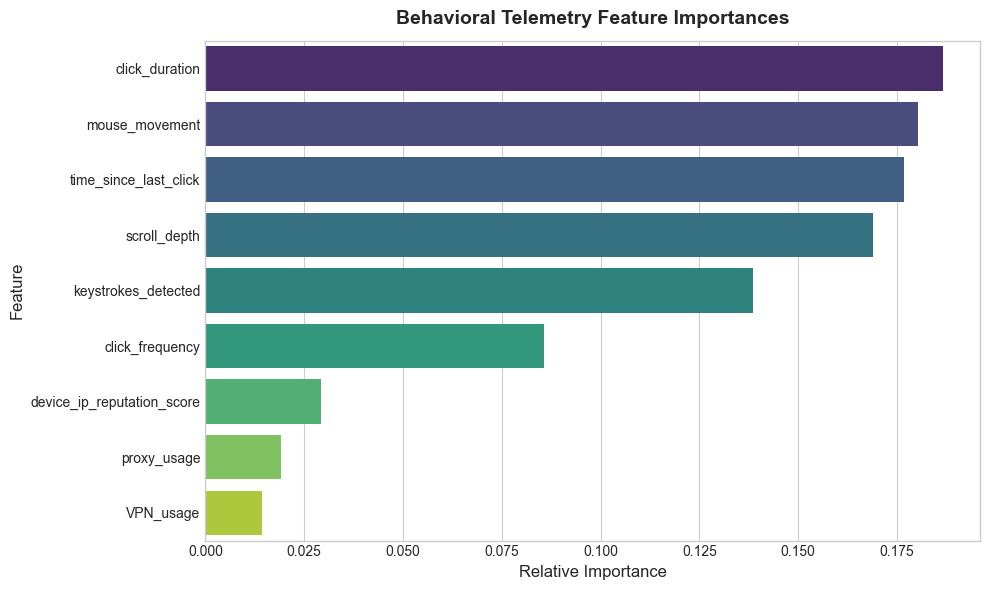

In [7]:
# Feature Importances
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[behavioral_features[i] for i in indices], palette='viridis')
plt.title('Behavioral Telemetry Feature Importances', fontsize=14, fontweight='bold', pad=12)
plt.xlabel('Relative Importance', fontsize=12)
plt.ylabel('Feature', fontsize=12)
plt.tight_layout()
plt.savefig('phase4_feature_importances.png', dpi=300)
plt.show()

## Step 7: Model & Scaler Serialization
Export the trained classifier and scaler artifacts to the `ml_core/behavioral_biometrics/` directory for live FastAPI inference.

In [8]:
os.makedirs('../ml_core/behavioral_biometrics', exist_ok=True)

joblib.dump(model, '../ml_core/behavioral_biometrics/behavioral_classifier.pkl')
joblib.dump(scaler, '../ml_core/behavioral_biometrics/scaler_p4.pkl')

print("Model serialized to: ml_core/behavioral_biometrics/behavioral_classifier.pkl")
print("Scaler serialized to: ml_core/behavioral_biometrics/scaler_p4.pkl")

Model serialized to: ml_core/behavioral_biometrics/behavioral_classifier.pkl
Scaler serialized to: ml_core/behavioral_biometrics/scaler_p4.pkl
